<p style ="text-align:center">
    <img src="https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Images/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>


# SAOP09 - Data Science For Business
## Prof. Eduardo Pécora


# Regressão Com Variáveis Categóricas
Tempo estimado: **25** minutos

## Objetivos

Após completar esta aula, você será capaz de:

* Codificar variáveis categóricas binárias e multi-categoria usando `OneHotEncoder`
* Identificar e corrigir inconsistências (categorias duplicadas) antes de codificar
* Evitar a armadilha da variável dummy (multicolinearidade) ao codificar múltiplas categorias

## Bibliotecas

In [17]:
# importando a biblioteca pandas para manipulação de dados
import pandas as pd

# Importando numpy para operações matemáticas
import numpy as np

# importando as bibliotecas do matplotlib e seaborn para gerar gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Único codificador de variáveis categóricas usado nesta aula
from sklearn.preprocessing import OneHotEncoder

# Classe de regressão e métricas de erro
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

%matplotlib inline

## Obtendo dados

In [18]:
# Caminho do arquivo csv
caminho = "https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Dados/MeuAutoLimpo.csv"

#Obtendo arquivo e passando-o para um dataframe
df = pd.read_csv(caminho)

df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,164,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


## Regressão Linear Com Variáveis Categóricas

### Variáveis Dicotômicas

In [19]:
df_num_of_doors = df[['price','engine-size', 'curb-weight','num-of-doors']].copy(deep=True)

df_num_of_doors.head()

,price,engine-size,curb-weight,num-of-doors
0,13495,130,2548,two
1,16500,130,2548,two
2,16500,152,2823,two
3,13950,109,2337,four
4,17450,136,2824,four


In [20]:
# Para uma variável com só duas categorias, drop='if_binary' cria uma única coluna 0/1
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
encoder_binario = OneHotEncoder(drop='if_binary')

resultado = encoder_binario.fit_transform(df_num_of_doors[['num-of-doors']])

# 1 = 'two', 0 = 'four' (confira com encoder_binario.get_feature_names_out())
df_num_of_doors['num-of-doors'] = resultado.toarray()

In [21]:
df_num_of_doors.head(10)

,price,engine-size,curb-weight,num-of-doors
0,13495,130,2548,1.0
1,16500,130,2548,1.0
2,16500,152,2823,1.0
3,13950,109,2337,0.0
4,17450,136,2824,0.0
5,15250,136,2507,1.0
6,17710,136,2844,0.0
7,18920,136,2954,0.0
8,23875,131,3086,0.0
9,16430,108,2395,1.0


### Variáveis Politômicas

In [22]:
df_make = df[['price','engine-size', 'curb-weight','make']].copy(deep=True)

df_make.head()

,price,engine-size,curb-weight,make
0,13495,130,2548,alfa-romero
1,16500,130,2548,alfa-romero
2,16500,152,2823,alfa-romero
3,13950,109,2337,audi
4,17450,136,2824,audi


## Verificando os valores e corrigindo os "duplicados"

In [23]:
df_categorias_make = pd.DataFrame({'cat': df_make['make'].unique()})
df_categorias_make

,cat
0,alfa-romero
1,audi
2,bmw
3,BMW
4,chevrolet
5,dodge
6,doge
7,honda
8,isuzu
9,jaguar


In [24]:
df_make['make'].unique()

array(['alfa-romero', 'audi', 'bmw', 'BMW', 'chevrolet', 'dodge', 'doge',
       'honda', 'isuzu', 'jaguar', 'mazda', 'mercedes-benz', 'mercury',
       'mitsubishi', 'nissan', 'peugot', 'plymouth', 'porsche', 'renault',
       'saab', 'subaru', 'toyota', 'volkswagen', 'VW', 'volv1', 'volvo'],
      dtype=object)

In [25]:
df_make['make'] = df_make['make'].replace({'bmw': 'BMW'})

In [26]:
df_categorias_make = pd.DataFrame({'cat': df_make['make'].unique()})
df_categorias_make

,cat
0,alfa-romero
1,audi
2,BMW
3,chevrolet
4,dodge
5,doge
6,honda
7,isuzu
8,jaguar
9,mazda


In [27]:
df_make['make'] = df_make['make'].replace({'doge': 'dodge', 'VW':'volkswagen', 'volv1':'volvo' })

df_categorias_make = pd.DataFrame({'cat': df_make['make'].unique()})
df_categorias_make

,cat
0,alfa-romero
1,audi
2,BMW
3,chevrolet
4,dodge
5,honda
6,isuzu
7,jaguar
8,mazda
9,mercedes-benz


### Evitando a armadilha da variável dummy

Se criarmos uma coluna dummy para **cada** categoria de `make` (as 22 categorias já corrigidas acima), essas colunas ficam perfeitamente correlacionadas entre si: sabendo o valor das outras 21, você sempre consegue deduzir a última. Isso é chamado de **armadilha da variável dummy**, e causa multicolinearidade perfeita — um problema para a interpretação dos coeficientes de um modelo de regressão.

Por isso usamos `drop='first'`: ele descarta uma das categorias como referência. O efeito dela não desaparece — fica embutido no intercepto do modelo.

In [28]:
# Criando uma instância do codificador OneHotEncoder, descartando a primeira categoria
# para evitar a armadilha da variável dummy
encoder_make = OneHotEncoder(drop='first')

# Ajustando e transformando os dados da coluna "make"
dummy_array = encoder_make.fit_transform(df_make[['make']])

# Conferindo qual categoria foi descartada, em vez de presumir
print("Categorias (na ordem usada pelo encoder):", encoder_make.categories_[0])
print("Categoria descartada:", encoder_make.categories_[0][encoder_make.drop_idx_[0]])

# Criando um DataFrame Pandas com as variáveis dummy
dummy_df = pd.DataFrame(dummy_array.toarray(), columns=encoder_make.get_feature_names_out(['make']))

# Concatenando o DataFrame dummy com os outros dados
df_make = pd.concat([df_make.drop('make', axis=1), dummy_df], axis=1)

df_make.head()

Categorias (na ordem usada pelo encoder): ['BMW' 'alfa-romero' 'audi' 'chevrolet' 'dodge' 'honda' 'isuzu' 'jaguar'
 'mazda' 'mercedes-benz' 'mercury' 'mitsubishi' 'nissan' 'peugot'
 'plymouth' 'porsche' 'renault' 'saab' 'subaru' 'toyota' 'volkswagen'
 'volvo']
Categoria descartada: BMW


,price,engine-size,curb-weight,make_alfa-romero,make_audi,make_chevrolet,make_dodge,make_honda,make_isuzu,make_jaguar,...,make_nissan,make_peugot,make_plymouth,make_porsche,make_renault,make_saab,make_subaru,make_toyota,make_volkswagen,make_volvo
0,13495,130,2548,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,16500,130,2548,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,16500,152,2823,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,13950,109,2337,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,17450,136,2824,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Repare que a categoria descartada foi `BMW`, não `alfa-romero` como seria de se esperar (a primeira em ordem alfabética "normal"). Isso acontece porque o critério de ordenação do encoder é a ordem lexicográfica do Python, em que letras maiúsculas vêm antes de minúsculas — e `BMW` é a única marca com essa capitalização. É um bom lembrete: **confira sempre** qual categoria foi de fato descartada (`encoder.categories_` e `encoder.drop_idx_`), em vez de presumir.

## Ajustando um modelo com a variável `make` codificada

Agora que `make` está codificada, podemos usá-la (junto com `engine-size` e `curb-weight`) em um modelo de regressão, exatamente como fizemos com variáveis numéricas nas aulas anteriores.

In [29]:
X = df_make.drop(columns=['price'])
Y = df_make['price']

lm = LinearRegression()
lm.fit(X, Y)

# Exibindo o R^2
R2 = lm.score(X, Y)

print("SCORE: %.4f" % R2)

SCORE: 0.9279


In [30]:
# Calculando o valor predito
df_make['YHat'] = lm.predict(X)

df_make[['price', 'YHat']].head()

,price,YHat
0,13495,14545.882871
1,16500,14545.882871
2,16500,17403.234257
3,13950,14211.713222
4,17450,18544.490882


### Comparando Previsto x Real

Vamos usar o recurso gráfico para visualizar esse erro.

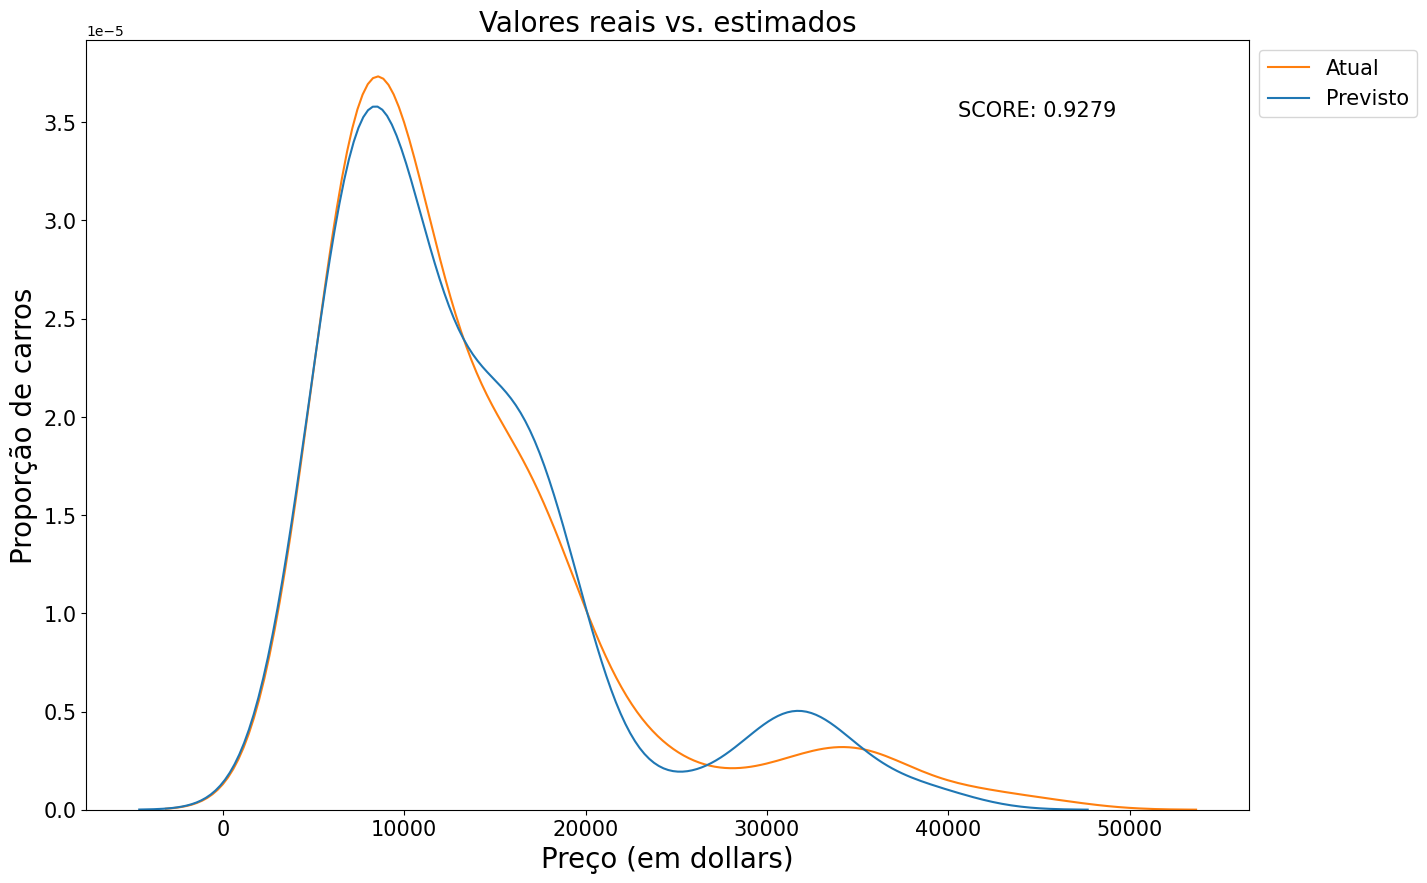

In [31]:
plt.figure(figsize=(15, 10))

sns.kdeplot(data=df_make[['YHat', 'price']])

plt.title('Valores reais vs. estimados', size=20)
plt.xlabel('Preço (em dollars)', size=20)
plt.ylabel('Proporção de carros', size=20)
plt.yticks(size=15)
plt.xticks(size=15)
plt.legend(labels=["Atual", "Previsto"], fontsize=15, bbox_to_anchor=(1, 1))

tt = "SCORE: %.4f" % R2
# Coordenadas relativas aos eixos (0 a 1), para o texto não depender da escala do preço
plt.text(0.75, 0.9, tt, size=15, transform=plt.gca().transAxes)
plt.show()

### Cálculo dos erros

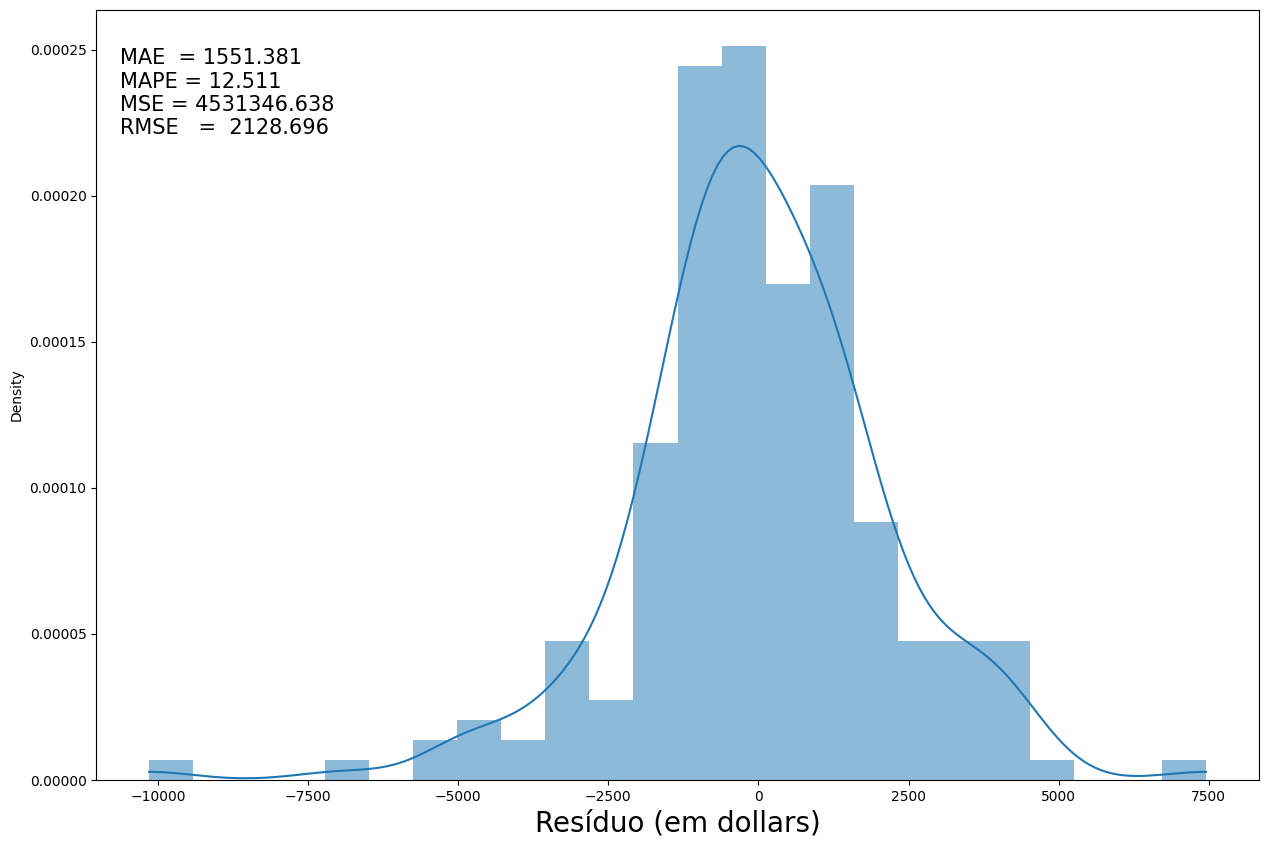

In [32]:
df_make['Deviation'] = df_make['YHat'] - df_make['price']

mae = mean_absolute_error(df_make['price'], df_make['YHat'])
mape = 100 * mean_absolute_percentage_error(df_make['price'], df_make['YHat'])
mse = mean_squared_error(df_make['price'], df_make['YHat'])
rmse = np.sqrt(mse)

plt.figure(figsize=(15, 10))

tt = "MAE  = %.3f \nMAPE = %.3f \nMSE = %.3f \nRMSE   =  %.3f" % (mae, mape, mse, rmse)

sns.histplot(x=df_make['Deviation'], kde=True, stat="density", linewidth=0)

# Coordenadas relativas aos eixos (0 a 1), para o texto não depender da escala dos resíduos
plt.text(0.02, 0.95, tt, size=15, color="black", transform=plt.gca().transAxes, va='top')
plt.xlabel('Resíduo (em dollars)', size=20)
plt.show()

## Para praticar

Até agora você codificou uma variável categórica de cada vez (`num_of_doors` e depois `make`, isoladamente). Sua tarefa agora é:

1. Identificar **todas** as colunas categóricas do dataset original (`df`) de uma vez (dica: `select_dtypes`);
2. Verificar se alguma delas tem os mesmos problemas de categorias duplicadas que encontramos em `make` (adapte o processo que fizemos acima para cada coluna);
3. Codificar todas elas de uma vez com `OneHotEncoder` — lembrando de usar `drop='first'` — e juntar o resultado com TODAS as colunas numéricas do dataset original em um único dataframe.

Depois de montar esse dataset completo, tente também validar um modelo de regressão treinado com ele usando `train_test_split` (técnica que você aprendeu na aula anterior): será que usar todas as variáveis resulta em um modelo melhor quando avaliado de forma justa, ou o desempenho no teste conta uma história diferente do que o $R^2$ no treino sugere?

### Próxima aula

Na próxima aula vamos reunir tudo o que aprendemos até aqui — regressão múltipla, variáveis categóricas e validação com treino/teste — em um caso real de negócio: estimar o custo de beneficiários de um plano de saúde.

## Fique Conectado

- [![YouTube](https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Images/youtube_icon_color.png)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Images/linkedin_icon_color.png)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Images/instagram_icon_color.png)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!


## Autores

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>, <a href="https://www.linkedin.com/in/hesauhugocavalcanti/" target="_blank">Hesau Hugo</a> , <a href="https://www.linkedin.com/in/joão-gabriel-santin-botelho/" target="_blank">João Gabriel</a>

## Referências:

Traduzido e inspirado do material desenvolvido pela IBM:
<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDA0101ENSkillsNetwork20235326-2021-01-01" target="_blank">Joseph Santarcangelo</a>
<br>

* Documentação da biblioteca <a href="https://pandas.pydata.org/docs/">Pandas</a>
* Documentação da biblioteca <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html">Scikit-learn (OneHotEncoder)</a>

## Log de modificações

| Data | Versão | Modificado por | Descrição |
| -----------| ------- | ---------- | ---------------------------------- |
| 04-04-2021       | 1.0     | Eduardo Pecora    | Inicial               |
| 03-11-2021       | 1.1     | Eduardo Pecora    | Estrutura Aula        |
| 08-03-2022       | 1.2     | Eduardo Pecora    | GitHub                |
| 17-04-2023       | 1.3     | Hesau Hugo        | Reestruturação        |
| 18-09-2024       | 1.4     | João Gabriel      | Atualização           |
| 01-09-2026       | 2.0     | Eduardo Pécora | Separação do conteúdo de Train-Test-Split para outro notebook |